<a href="https://colab.research.google.com/github/hitarthi45/Artificial-Intelligence/blob/main/Exp_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/content/DailyDelhiClimateTest.csv')
data.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


In [ ]:
data.describe()

,meantemp,humidity,wind_speed,meanpressure
count,114.000000,114.000000,114.000000,114.000000
mean,21.713079,56.258362,8.143924,1004.035090
std,6.360072,19.068083,3.588049,89.474692
min,11.000000,17.750000,1.387500,59.000000
25%,16.437198,39.625000,5.563542,1007.437500
50%,19.875000,57.750000,8.069444,1012.739316
75%,27.705357,71.902778,10.068750,1016.739583
max,34.500000,95.833333,19.314286,1022.809524


In [ ]:
data.shape

(114, 5)

In [ ]:
target = 'meantemp'
X = data.drop([target], axis=1)
y = data[target]

In [ ]:
print(data.isnull().sum())

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


In [ ]:
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
# Exclude 'meantemp' from the list as it's the target variable and not needed for this visualization
# and 'date' is not a numerical feature, it should be handled separately if needed.
if 'meantemp' in numerical_cols:
    numerical_cols.remove('meantemp')

print("Numerical columns identified for box plots:", numerical_cols)

Numerical columns identified for box plots: ['humidity', 'wind_speed', 'meanpressure']


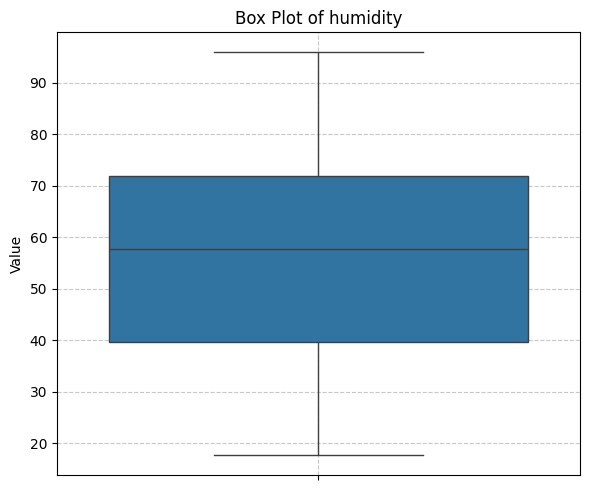

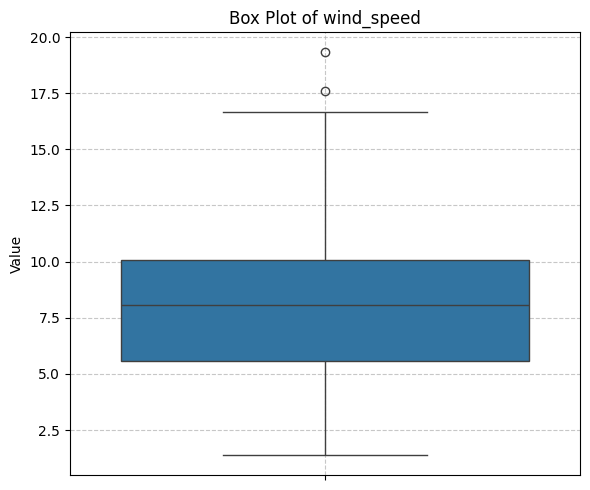

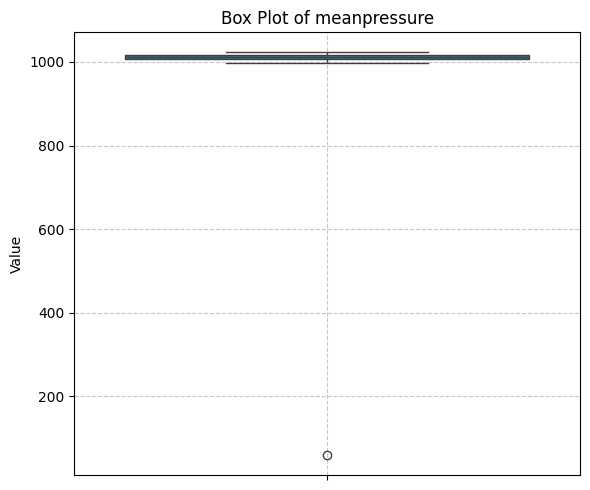

In [ ]:
for col in numerical_cols:
    plt.figure(figsize=(6, 5))
    sns.boxplot(y=data[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('Value')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


In [ ]:
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]

    print(f"\n--- Analysis for {col} ---")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower Bound for Outliers: {lower_bound:.2f}")
    print(f"Upper Bound for Outliers: {upper_bound:.2f}")

    if not outliers.empty:
        print(f"Number of outliers: {len(outliers)}")
        print(f"Outlier values:\n{outliers}")
        print(f"Potential Impact: Outliers in '{col}' could significantly skew statistical measures like mean and standard deviation, potentially affecting model training if not handled.")
    else:
        print("No outliers detected within the 1.5*IQR range.")



--- Analysis for humidity ---
Q1: 39.62
Q3: 71.90
IQR: 32.28
Lower Bound for Outliers: -8.79
Upper Bound for Outliers: 120.32
No outliers detected within the 1.5*IQR range.

--- Analysis for wind_speed ---
Q1: 5.56
Q3: 10.07
IQR: 4.51
Lower Bound for Outliers: -1.19
Upper Bound for Outliers: 16.83
Number of outliers: 2
Outlier values:
84    17.590000
99    19.314286
Name: wind_speed, dtype: float64
Potential Impact: Outliers in 'wind_speed' could significantly skew statistical measures like mean and standard deviation, potentially affecting model training if not handled.

--- Analysis for meanpressure ---
Q1: 1007.44
Q3: 1016.74
IQR: 9.30
Lower Bound for Outliers: 993.48
Upper Bound for Outliers: 1030.69
Number of outliers: 1
Outlier values:
0    59.0
Name: meanpressure, dtype: float64
Potential Impact: Outliers in 'meanpressure' could significantly skew statistical measures like mean and standard deviation, potentially affecting model training if not handled.
